In [139]:
import numpy as np
import pandas as pd
import seaborn as sns


# df = pd.DataFrame(np.random.rand(30000, 1), columns = list('C'))
# df['A'] = np.random.choice(range(2), 30000)
# df['B'] = np.random.choice(range(2), 30000)

records = [{
        "A": 1, 
        "B": 0,
        "C":9
    }]

for _ in range(30000):
    a = np.random.choice(range(2))
    b = np.random.choice(range(2))
    if a == 1:
        c  = np.random.rand()
    else: 
        c  = 10 * np.random.rand()
    records.append({
        "A": a,
        "B":b, 
        "C":c,
    })


df = pd.DataFrame(records)
# def get_max_rows(df):
#     groups = df.groupby(by=['A','B'])
#     return groups.apply(lambda g: g[g['C'] == g['C'].max()])
# df = df.set_index("A")

def filter_iqr(df,groupby, col):
    """
    filter_iqr(df,["A","B"],"C")
    """
    threshold = 1.5
    groups = df.groupby(by=groupby)
    filt =  groups.apply(lambda g: g[~((g[col] < g[col].quantile(0.25) - threshold * (g[col].quantile(0.75) - g[col].quantile(0.25))) | (g[col] > g[col].quantile(0.75) + threshold * (g[col].quantile(0.75) - g[col].quantile(0.25))))])
    outliers =  groups.apply(lambda g: g[(g[col] < g[col].quantile(0.25) - threshold * (g[col].quantile(0.75) - g[col].quantile(0.25))) | (g[col] > g[col].quantile(0.75) + threshold * (g[col].quantile(0.75) - g[col].quantile(0.25)))])
    return filt,outliers



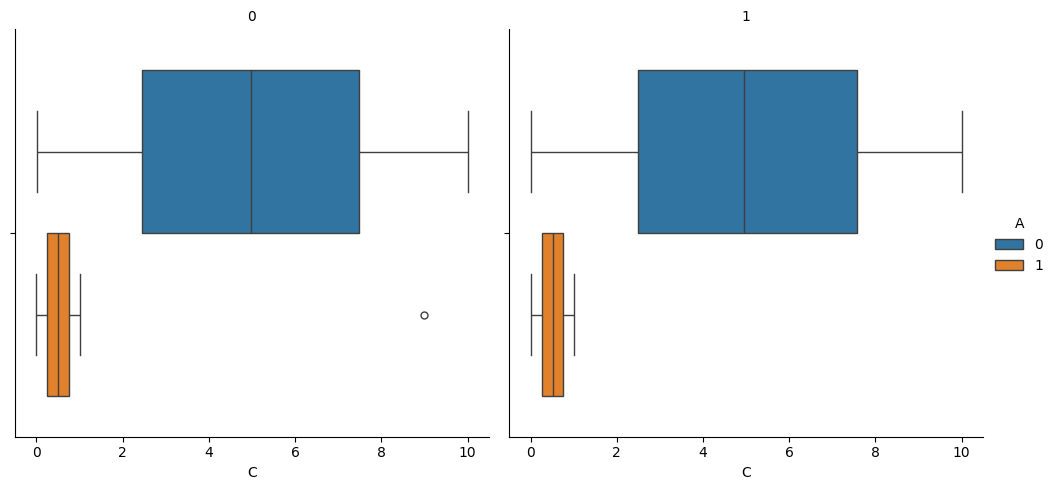

In [136]:
g = sns.catplot(df,x="C",col="B",hue="A",kind="box",sharex=False);
g.set_titles(col_template="{col_name}", row_template="{row_name}")


In [137]:
threshold = 1.5
# Calculate IQR for column CD loss
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
IQR

outliers = (df < Q1 - threshold * IQR) | (df > Q3 + threshold * IQR)

outliers.describe()

# df_clean = df.drop(outliers)

,A,B,C
count,30001,30001,30001
unique,1,1,1
top,False,False,False
freq,30001,30001,30001


In [140]:
filtered, outliers = filter_iqr(df,["A","B"],"C")

In [141]:
outliers

,,,A,B,C
A,B,,,,
1,0,0,1,0,9.0


In [142]:
filtered

A  B         C
A B                      
0 0 5      0  0  3.869093
    6      0  0  2.379954
    17     0  0  2.391245
    18     0  0  3.292004
    29     0  0  7.337366
...       .. ..       ...
1 1 29984  1  1  0.738555
    29988  1  1  0.466909
    29989  1  1  0.108806
    29991  1  1  0.124258
    29996  1  1  0.440651

[30000 rows x 3 columns]

In [131]:
cheese = pd.DataFrame(
    {
        "first": ["John", "Mary"],
        "last": ["Doe", "Bo"],
        "height": [5.5, 6.0],
        "weight": [130, 150],
    }
)
cheese

,first,last,height,weight
0,John,Doe,5.5,130
1,Mary,Bo,6.0,150


In [132]:
cheese.melt(id_vars=["first", "last"], ignore_index=False,value_name="bad",var_name="HEllo")

,first,last,HEllo,bad
0,John,Doe,height,5.5
1,Mary,Bo,height,6.0
0,John,Doe,weight,130.0
1,Mary,Bo,weight,150.0


  type   IR
0    a  0.1
1    b  0.3
2    b  0.2
3    c  0.8
4    c  0.5


C:\Users\ernst\AppData\Local\Temp\ipykernel_20920\295979075.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.displot(df, x='IR', kind="kde", hue='type')


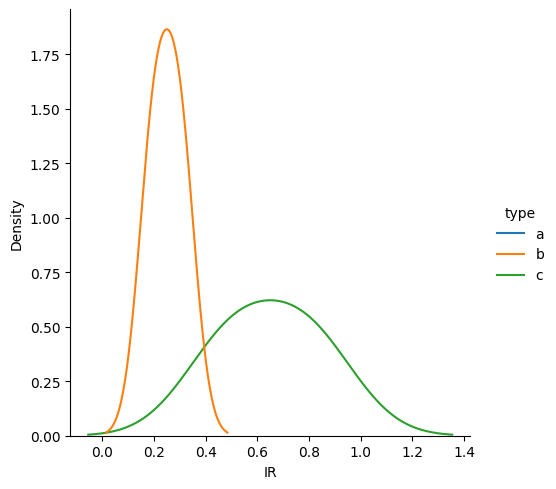

In [133]:
df = pd.DataFrame({'type': {0: 'a', 1: 'b', 2: 'b', 3: 'c', 4: 'c'}, 
                   'IR': {0: 0.1, 1: 0.3, 2: 0.2, 3: 0.8, 4: 0.5}})
print (df)
sns.displot(df, x='IR', kind="kde", hue='type')


C:\Users\ernst\AppData\Local\Temp\ipykernel_20920\2922281372.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.displot(df, x='IR',kind="kde", hue='type', rug=True)


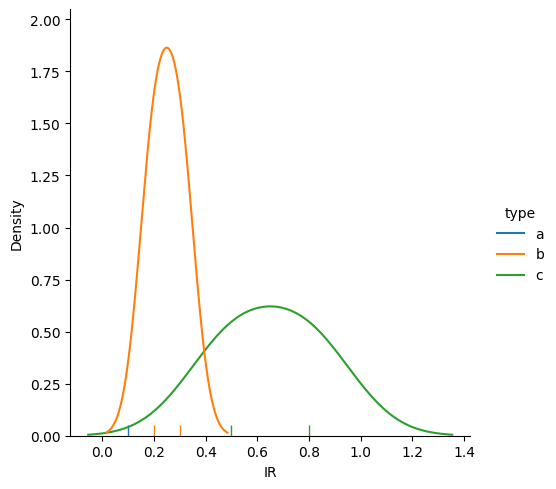

In [134]:
sns.displot(df, x='IR',kind="kde", hue='type', rug=True)
